# NAM Raman — Frequency Shift & Spectral Similarity Analysis
**Sections:**
1. Frequency Shift / Error Analysis (Peak Matching)
2. Spectral Similarity Analysis (Cosine Similarity + Pearson Correlation)

> Run this notebook **after** `NAM_Raman_Analysis.ipynb` has generated:
> - `peak_matching_table.csv`
> - `processed_<best_spectrum>.csv`
> - `simdata.xlsx`

---
## ⚙️ Configuration — Set Your Paths Here

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import warnings
warnings.filterwarnings('ignore')

from scipy.interpolate import interp1d
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# ── PATHS ────────────────────────────────────────────────────────────────────
OUTPUT_DIR       = r"C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\output_figures"
PEAK_MATCH_CSV   = os.path.join(OUTPUT_DIR, 'peak_matching_table.csv')

# Best processed experimental spectrum CSV (ranked #1: sec-25, power-80)
BEST_EXP_CSV     = os.path.join(OUTPUT_DIR, 'processed_sec-25_power-80_i-2.csv')

# DFT simulation file
SIM_FILE         = r"C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\simdata.xlsx"

# ── DFT PARAMETERS ───────────────────────────────────────────────────────────
DFT_SCALE        = 0.96
GAUSS_SIGMA      = 10      # cm⁻¹

# ── COMMON GRID ──────────────────────────────────────────────────────────────
GRID_START       = 200     # cm⁻¹
GRID_END         = 1800    # cm⁻¹
GRID_STEP        = 1       # cm⁻¹

plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 12,
    'axes.grid': True, 'grid.alpha': 0.3,
    'legend.fontsize': 10, 'lines.linewidth': 1.5
})

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('✅ Libraries loaded. Paths configured.')
print(f'   Best spectrum : {os.path.basename(BEST_EXP_CSV)}')
print(f'   Peak match CSV: {os.path.basename(PEAK_MATCH_CSV)}')


✅ Libraries loaded. Paths configured.
   Best spectrum : processed_sec-25_power-80_i-2.csv
   Peak match CSV: peak_matching_table.csv


---
# Part 1 — Frequency Shift / Error Analysis

## 1.1 — Load Peak Matching Table

In [2]:
df_match = pd.read_csv(PEAK_MATCH_CSV, index_col=0)

# Rename columns defensively
df_match.columns = [c.strip() for c in df_match.columns]

EXP_COL  = [c for c in df_match.columns if 'Experimental' in c][0]
SIM_COL  = [c for c in df_match.columns if 'Simulated'    in c][0]
DIFF_COL = [c for c in df_match.columns if 'Difference'   in c][0]

exp_peaks = df_match[EXP_COL].values
sim_peaks = df_match[SIM_COL].values
error     = exp_peaks - sim_peaks   # positive → sim too low; negative → sim too high

df_match['Error (cm⁻¹)'] = error

print(f'✅ Loaded {len(df_match)} matched peaks.\n')
print(df_match[[EXP_COL, SIM_COL, 'Error (cm⁻¹)']].to_string())

✅ Loaded 51 matched peaks.

    Experimental (cm⁻¹)  DFT Simulated (cm⁻¹)  Error (cm⁻¹)
1                 231.4                 230.4           1.0
2                 256.0                 253.4           2.6
3                 286.2                 284.2           2.0
4                 316.2                 314.9           1.3
5                 349.8                 353.3          -3.5
6                 368.3                 368.6          -0.3
7                 458.2                 460.8          -2.6
8                 489.0                 491.5          -2.5
9                 523.1                 522.2           0.9
10                541.0                 537.6           3.4
11                583.7                 583.7           0.0
12                615.4                 614.4           1.0
13                645.2                 645.1           0.1
14                676.6                 675.8           0.8
15                702.5                 698.9           3.6
16          

## 1.2 — Compute Error Statistics

In [3]:
mean_error   = np.mean(error)
median_error = np.median(error)
std_error    = np.std(error, ddof=1)
rmse         = np.sqrt(np.mean(error**2))
max_abs_err  = np.max(np.abs(error))

# Quality assessment
if rmse < 5:
    rmse_quality = '🟢 Excellent  (< 5 cm⁻¹)'
elif rmse < 10:
    rmse_quality = '🟡 Good       (5–10 cm⁻¹)'
else:
    rmse_quality = '🔴 Poor       (> 10 cm⁻¹)'

if abs(mean_error) < 2:
    scale_interp = '✅ Scaling factor (0.96) appears correct — mean error near 0'
elif mean_error > 2:
    scale_interp = '⚠️  Simulated frequencies slightly too LOW — consider increasing scale factor'
else:
    scale_interp = '⚠️  Simulated frequencies slightly too HIGH — consider decreasing scale factor'

print('═' * 52)
print('  FREQUENCY SHIFT ERROR STATISTICS')
print('═' * 52)
print(f'  Number of matched peaks  : {len(error)}')
print(f'  Mean error               : {mean_error:+.3f} cm⁻¹')
print(f'  Median error             : {median_error:+.3f} cm⁻¹')
print(f'  Std deviation            : {std_error:.3f} cm⁻¹')
print(f'  RMSE                     : {rmse:.3f} cm⁻¹  →  {rmse_quality}')
print(f'  Max absolute error       : {max_abs_err:.3f} cm⁻¹')
print(f'\n  Interpretation: {scale_interp}')
print('═' * 52)

════════════════════════════════════════════════════
  FREQUENCY SHIFT ERROR STATISTICS
════════════════════════════════════════════════════
  Number of matched peaks  : 51
  Mean error               : +0.378 cm⁻¹
  Median error             : +0.400 cm⁻¹
  Std deviation            : 2.102 cm⁻¹
  RMSE                     : 2.115 cm⁻¹  →  🟢 Excellent  (< 5 cm⁻¹)
  Max absolute error       : 3.800 cm⁻¹

  Interpretation: ✅ Scaling factor (0.96) appears correct — mean error near 0
════════════════════════════════════════════════════


## 1.3 — Error Distribution Histogram

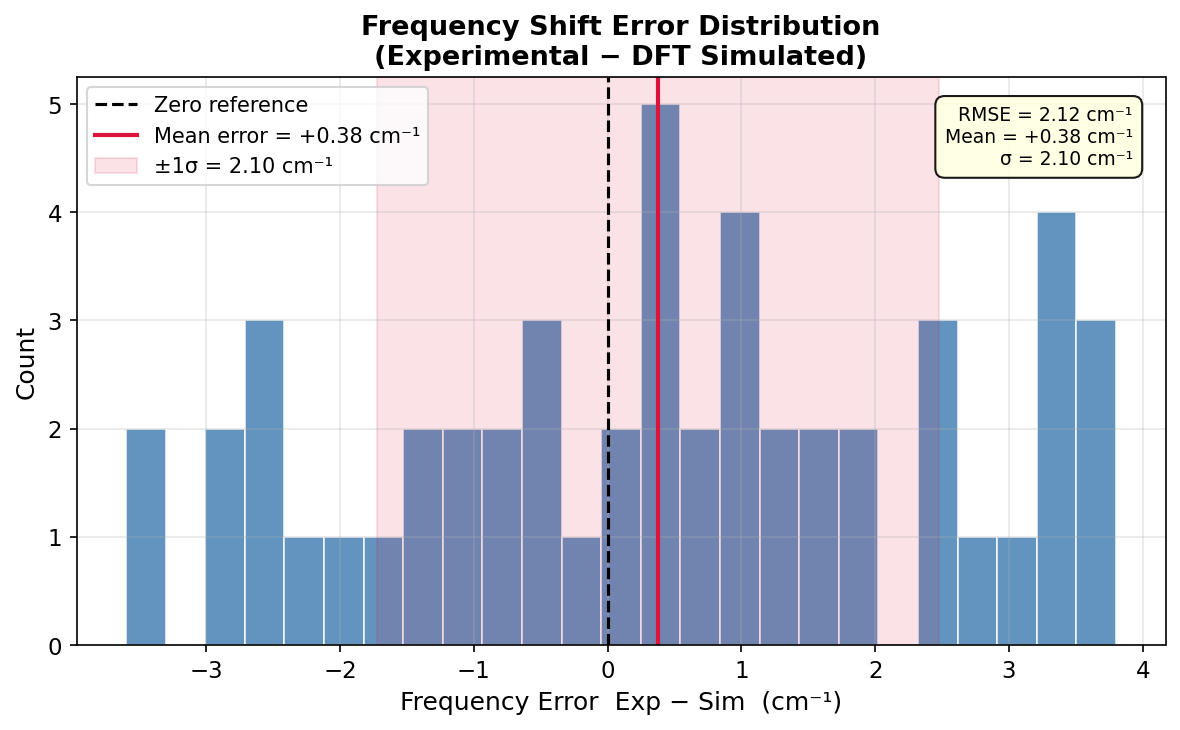

💾 Saved → C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\output_figures\fig07_frequency_error_histogram.png


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

n_bins = max(8, len(error) // 2)
counts, bins, patches = ax.hist(error, bins=n_bins,
                                 color='steelblue', edgecolor='white',
                                 alpha=0.85, linewidth=0.8)

# Mean and zero reference lines
ax.axvline(0,          color='black',  linestyle='--', linewidth=1.5, label='Zero reference')
ax.axvline(mean_error, color='crimson',linestyle='-',  linewidth=2.0,
           label=f'Mean error = {mean_error:+.2f} cm⁻¹')

# ±std shading
ax.axvspan(mean_error - std_error, mean_error + std_error,
           alpha=0.12, color='crimson', label=f'±1σ = {std_error:.2f} cm⁻¹')

ax.set_xlabel('Frequency Error  Exp − Sim  (cm⁻¹)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Frequency Shift Error Distribution\n(Experimental − DFT Simulated)', fontsize=13, fontweight='bold')
ax.legend()

# Annotation box
stats_text = (f'RMSE = {rmse:.2f} cm⁻¹\n'
              f'Mean = {mean_error:+.2f} cm⁻¹\n'
              f'σ = {std_error:.2f} cm⁻¹')
ax.text(0.97, 0.95, stats_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'fig07_frequency_error_histogram.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f'💾 Saved → {save_path}')

## 1.4 — Error vs Raman Shift (Systematic Trend Check)

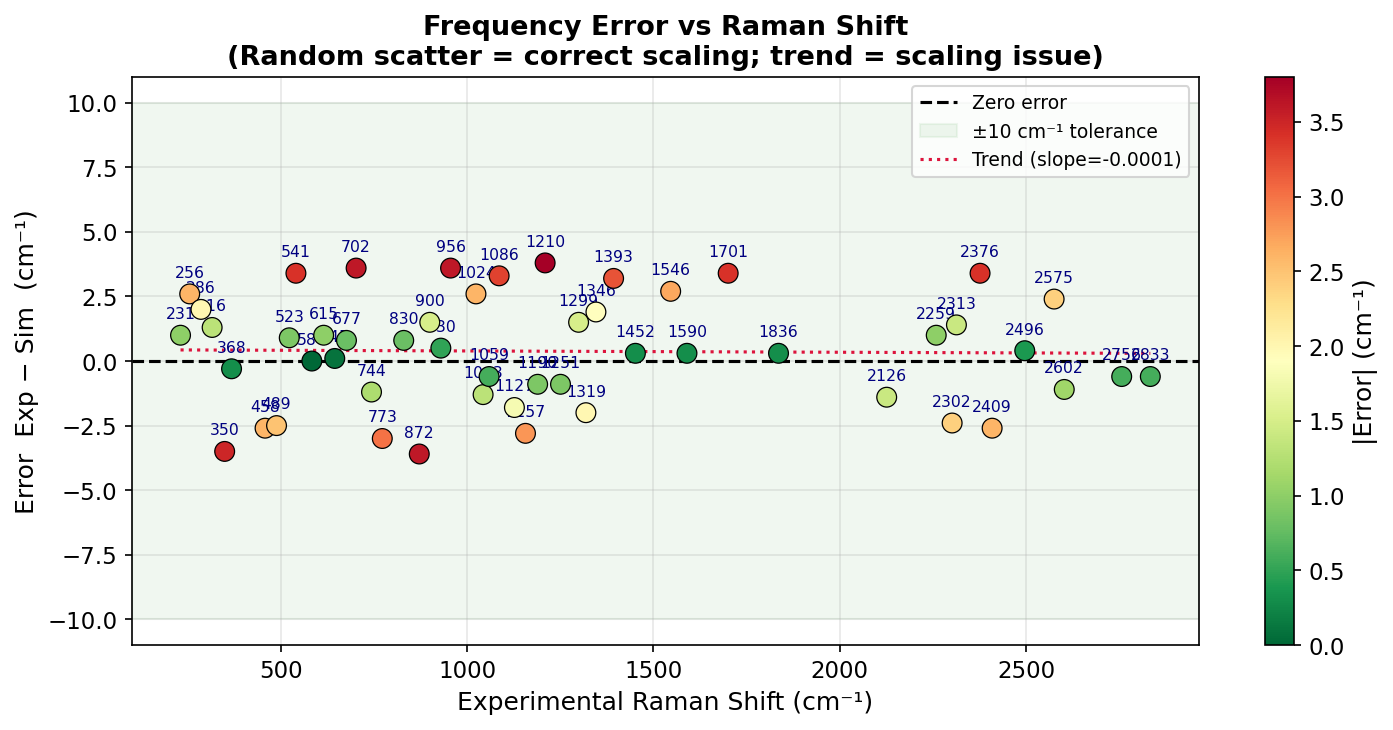

💾 Saved → C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\output_figures\fig08_error_vs_raman_shift.png


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

sc = ax.scatter(exp_peaks, error, c=np.abs(error),
                cmap='RdYlGn_r', s=90, edgecolors='k',
                linewidths=0.6, zorder=5)
plt.colorbar(sc, ax=ax, label='|Error| (cm⁻¹)')

# Zero reference
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Zero error')

# ±tolerance band
ax.axhspan(-10, 10, alpha=0.06, color='green', label='±10 cm⁻¹ tolerance')

# Annotate each point with its shift value
for xp, ye in zip(exp_peaks, error):
    ax.annotate(f'{xp:.0f}', (xp, ye),
                xytext=(0, 8), textcoords='offset points',
                fontsize=7.5, ha='center', color='navy')

# Trend line
if len(exp_peaks) > 2:
    z = np.polyfit(exp_peaks, error, 1)
    p = np.poly1d(z)
    x_line = np.linspace(exp_peaks.min(), exp_peaks.max(), 200)
    ax.plot(x_line, p(x_line), color='crimson', linestyle=':',
            linewidth=1.5, label=f'Trend (slope={z[0]:.4f})')

ax.set_xlabel('Experimental Raman Shift (cm⁻¹)', fontsize=12)
ax.set_ylabel('Error  Exp − Sim  (cm⁻¹)', fontsize=12)
ax.set_title('Frequency Error vs Raman Shift\n(Random scatter = correct scaling; trend = scaling issue)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'fig08_error_vs_raman_shift.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f'💾 Saved → {save_path}')

---
# Part 2 — Spectral Similarity Analysis

## 2.1 — Load Experimental & Simulate Spectra

In [6]:
# ── Load best experimental spectrum ─────────────────────────────────────────
df_exp = pd.read_csv(BEST_EXP_CSV)
shift_exp_col    = df_exp.columns[0]
intensity_exp_col= df_exp.columns[1]
raman_shift_exp  = df_exp[shift_exp_col].values
intensity_exp    = df_exp[intensity_exp_col].values

print(f'✅ Experimental spectrum loaded: {len(raman_shift_exp)} points')
print(f'   Range: {raman_shift_exp.min():.1f} – {raman_shift_exp.max():.1f} cm⁻¹')

# ── Load DFT simulation ──────────────────────────────────────────────────────
df_sim = pd.read_excel(SIM_FILE)
FREQ_COL     = df_sim.columns[0]
ACTIVITY_COL = df_sim.columns[1]
df_sim = df_sim[[FREQ_COL, ACTIVITY_COL]].copy()
df_sim.columns = ['frequency', 'activity']
df_sim = df_sim.dropna()
df_sim = df_sim[df_sim['frequency'] > 0]
df_sim['scaled_freq']   = df_sim['frequency'] * DFT_SCALE
df_sim['norm_activity'] = df_sim['activity'] / df_sim['activity'].max()

print(f'\n✅ DFT data loaded: {len(df_sim)} vibrational modes')
print(f'   Scaled range: {df_sim["scaled_freq"].min():.1f} – {df_sim["scaled_freq"].max():.1f} cm⁻¹')

✅ Experimental spectrum loaded: 1922 points
   Range: 200.8 – 2841.9 cm⁻¹

✅ DFT data loaded: 499 vibrational modes
   Scaled range: 7.7 – 3832.3 cm⁻¹


## 2.2 — Gaussian Broadening of DFT Stick Spectrum

In [7]:
def gaussian_broadening(x_grid, stick_freqs, stick_intensities, sigma=10):
    """Convert discrete DFT sticks → continuous Gaussian-broadened spectrum."""
    y = np.zeros_like(x_grid, dtype=float)
    for freq, inten in zip(stick_freqs, stick_intensities):
        y += inten * np.exp(-0.5 * ((x_grid - freq) / sigma) ** 2)
    return y

# Broadened on experimental shift axis first (for overlay)
y_sim_broad_exp = gaussian_broadening(
    raman_shift_exp,
    df_sim['scaled_freq'].values,
    df_sim['norm_activity'].values,
    sigma=GAUSS_SIGMA
)
if y_sim_broad_exp.max() > 0:
    y_sim_broad_exp /= y_sim_broad_exp.max()

print(f'✅ Gaussian broadening applied (σ = {GAUSS_SIGMA} cm⁻¹).')

✅ Gaussian broadening applied (σ = 10 cm⁻¹).


## 2.3 — Interpolate onto Common Grid

In [8]:
# Common Raman shift grid
common_grid = np.arange(GRID_START, GRID_END + GRID_STEP, GRID_STEP, dtype=float)

# Interpolate experimental spectrum
f_exp      = interp1d(raman_shift_exp, intensity_exp, bounds_error=False, fill_value=0.0)
exp_interp = f_exp(common_grid)

# Interpolate DFT broadened spectrum on common grid
y_sim_broad_common = gaussian_broadening(
    common_grid,
    df_sim['scaled_freq'].values,
    df_sim['norm_activity'].values,
    sigma=GAUSS_SIGMA
)
f_sim      = interp1d(common_grid, y_sim_broad_common, bounds_error=False, fill_value=0.0)
sim_interp = f_sim(common_grid)

# Normalize both (shape comparison, not magnitude)
exp_interp = exp_interp / np.max(exp_interp) if np.max(exp_interp) > 0 else exp_interp
sim_interp = sim_interp / np.max(sim_interp) if np.max(sim_interp) > 0 else sim_interp

print(f'✅ Both spectra interpolated onto common grid: {GRID_START}–{GRID_END} cm⁻¹ (step = {GRID_STEP} cm⁻¹)')
print(f'   Grid points: {len(common_grid)}')

✅ Both spectra interpolated onto common grid: 200–1800 cm⁻¹ (step = 1 cm⁻¹)
   Grid points: 1601


## 2.4 — Compute Cosine Similarity & Pearson Correlation

In [9]:
# Cosine similarity
cos_sim = cosine_similarity(
    exp_interp.reshape(1, -1),
    sim_interp.reshape(1, -1)
)[0][0]

# Pearson correlation
pearson_corr, pearson_pval = pearsonr(exp_interp, sim_interp)

# Quality ratings
def rate(score):
    if score >= 0.90: return '🟢 Excellent'
    elif score >= 0.80: return '🟡 Good'
    elif score >= 0.60: return '🟠 Moderate'
    else: return '🔴 Poor'

print('═' * 52)
print('  SPECTRAL SIMILARITY RESULTS')
print('═' * 52)
print(f'  Cosine Similarity   : {cos_sim:.4f}   →  {rate(cos_sim)}')
print(f'  Pearson Correlation : {pearson_corr:.4f}   →  {rate(pearson_corr)}')
print(f'  Pearson p-value     : {pearson_pval:.2e}')
print(f'  Grid range          : {GRID_START}–{GRID_END} cm⁻¹')
print(f'  DFT scale factor    : {DFT_SCALE}')
print(f'  Gaussian sigma      : {GAUSS_SIGMA} cm⁻¹')
print('═' * 52)

════════════════════════════════════════════════════
  SPECTRAL SIMILARITY RESULTS
════════════════════════════════════════════════════
  Cosine Similarity   : 0.5868   →  🔴 Poor
  Pearson Correlation : 0.1710   →  🔴 Poor
  Pearson p-value     : 5.73e-12
  Grid range          : 200–1800 cm⁻¹
  DFT scale factor    : 0.96
  Gaussian sigma      : 10 cm⁻¹
════════════════════════════════════════════════════


## 2.5 — Spectral Overlay Plot

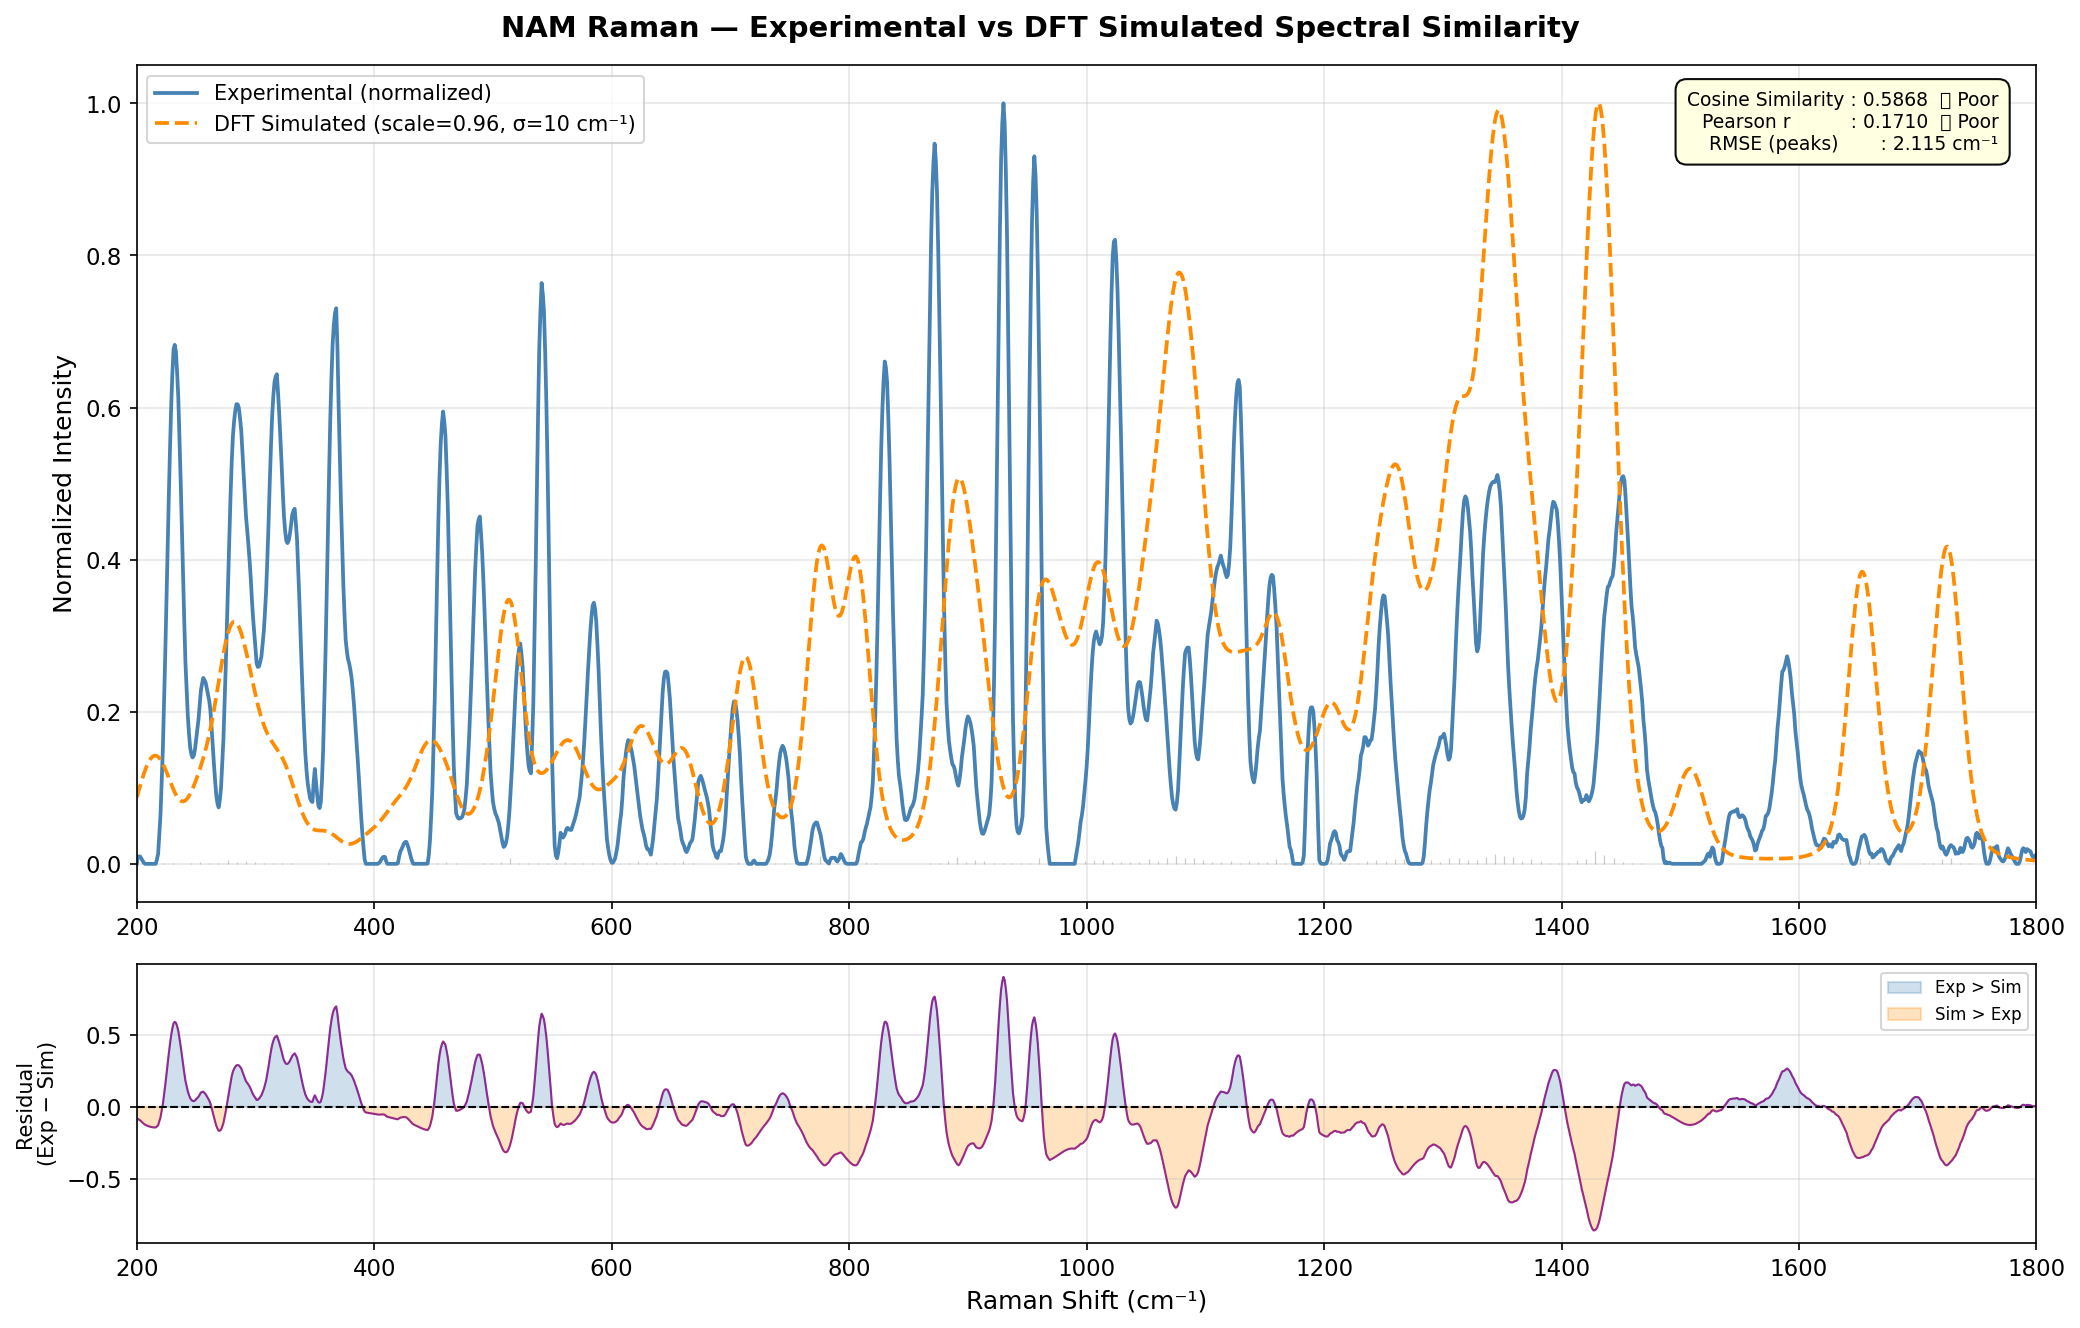

💾 Saved → C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\output_figures\fig09_spectral_similarity_overlay.png


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9),
                          gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('NAM Raman — Experimental vs DFT Simulated Spectral Similarity',
             fontsize=14, fontweight='bold')

# ── Top panel: Overlay ───────────────────────────────────────────────────────
ax = axes[0]
ax.plot(common_grid, exp_interp,
        color='steelblue', linewidth=1.8,
        label='Experimental (normalized)')
ax.plot(common_grid, sim_interp,
        color='darkorange', linewidth=1.8, linestyle='--',
        label=f'DFT Simulated (scale={DFT_SCALE}, σ={GAUSS_SIGMA} cm⁻¹)')

# DFT sticks
for _, drow in df_sim.iterrows():
    if GRID_START <= drow['scaled_freq'] <= GRID_END:
        ax.vlines(drow['scaled_freq'], 0,
                  drow['norm_activity'] * 0.25,
                  color='gray', linewidth=0.6, alpha=0.4)

# Similarity score box
score_text = (f'Cosine Similarity : {cos_sim:.4f}  {rate(cos_sim)}\n'
              f'Pearson r          : {pearson_corr:.4f}  {rate(pearson_corr)}\n'
              f'RMSE (peaks)       : {rmse:.3f} cm⁻¹')
ax.text(0.98, 0.97, score_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.6', facecolor='lightyellow', alpha=0.95))

ax.set_ylabel('Normalized Intensity', fontsize=12)
ax.set_xlim(GRID_START, GRID_END)
ax.legend(loc='upper left')

# ── Bottom panel: Residual (difference) ─────────────────────────────────────
ax2 = axes[1]
residual = exp_interp - sim_interp
ax2.plot(common_grid, residual, color='purple', linewidth=1, alpha=0.8)
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.fill_between(common_grid, residual, 0,
                  where=(residual > 0), alpha=0.25, color='steelblue', label='Exp > Sim')
ax2.fill_between(common_grid, residual, 0,
                  where=(residual < 0), alpha=0.25, color='darkorange', label='Sim > Exp')
ax2.set_xlabel('Raman Shift (cm⁻¹)', fontsize=12)
ax2.set_ylabel('Residual\n(Exp − Sim)', fontsize=10)
ax2.set_xlim(GRID_START, GRID_END)
ax2.legend(fontsize=8, loc='upper right')

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'fig09_spectral_similarity_overlay.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f'💾 Saved → {save_path}')

## 2.6 — Combined Validation Summary (4-panel)

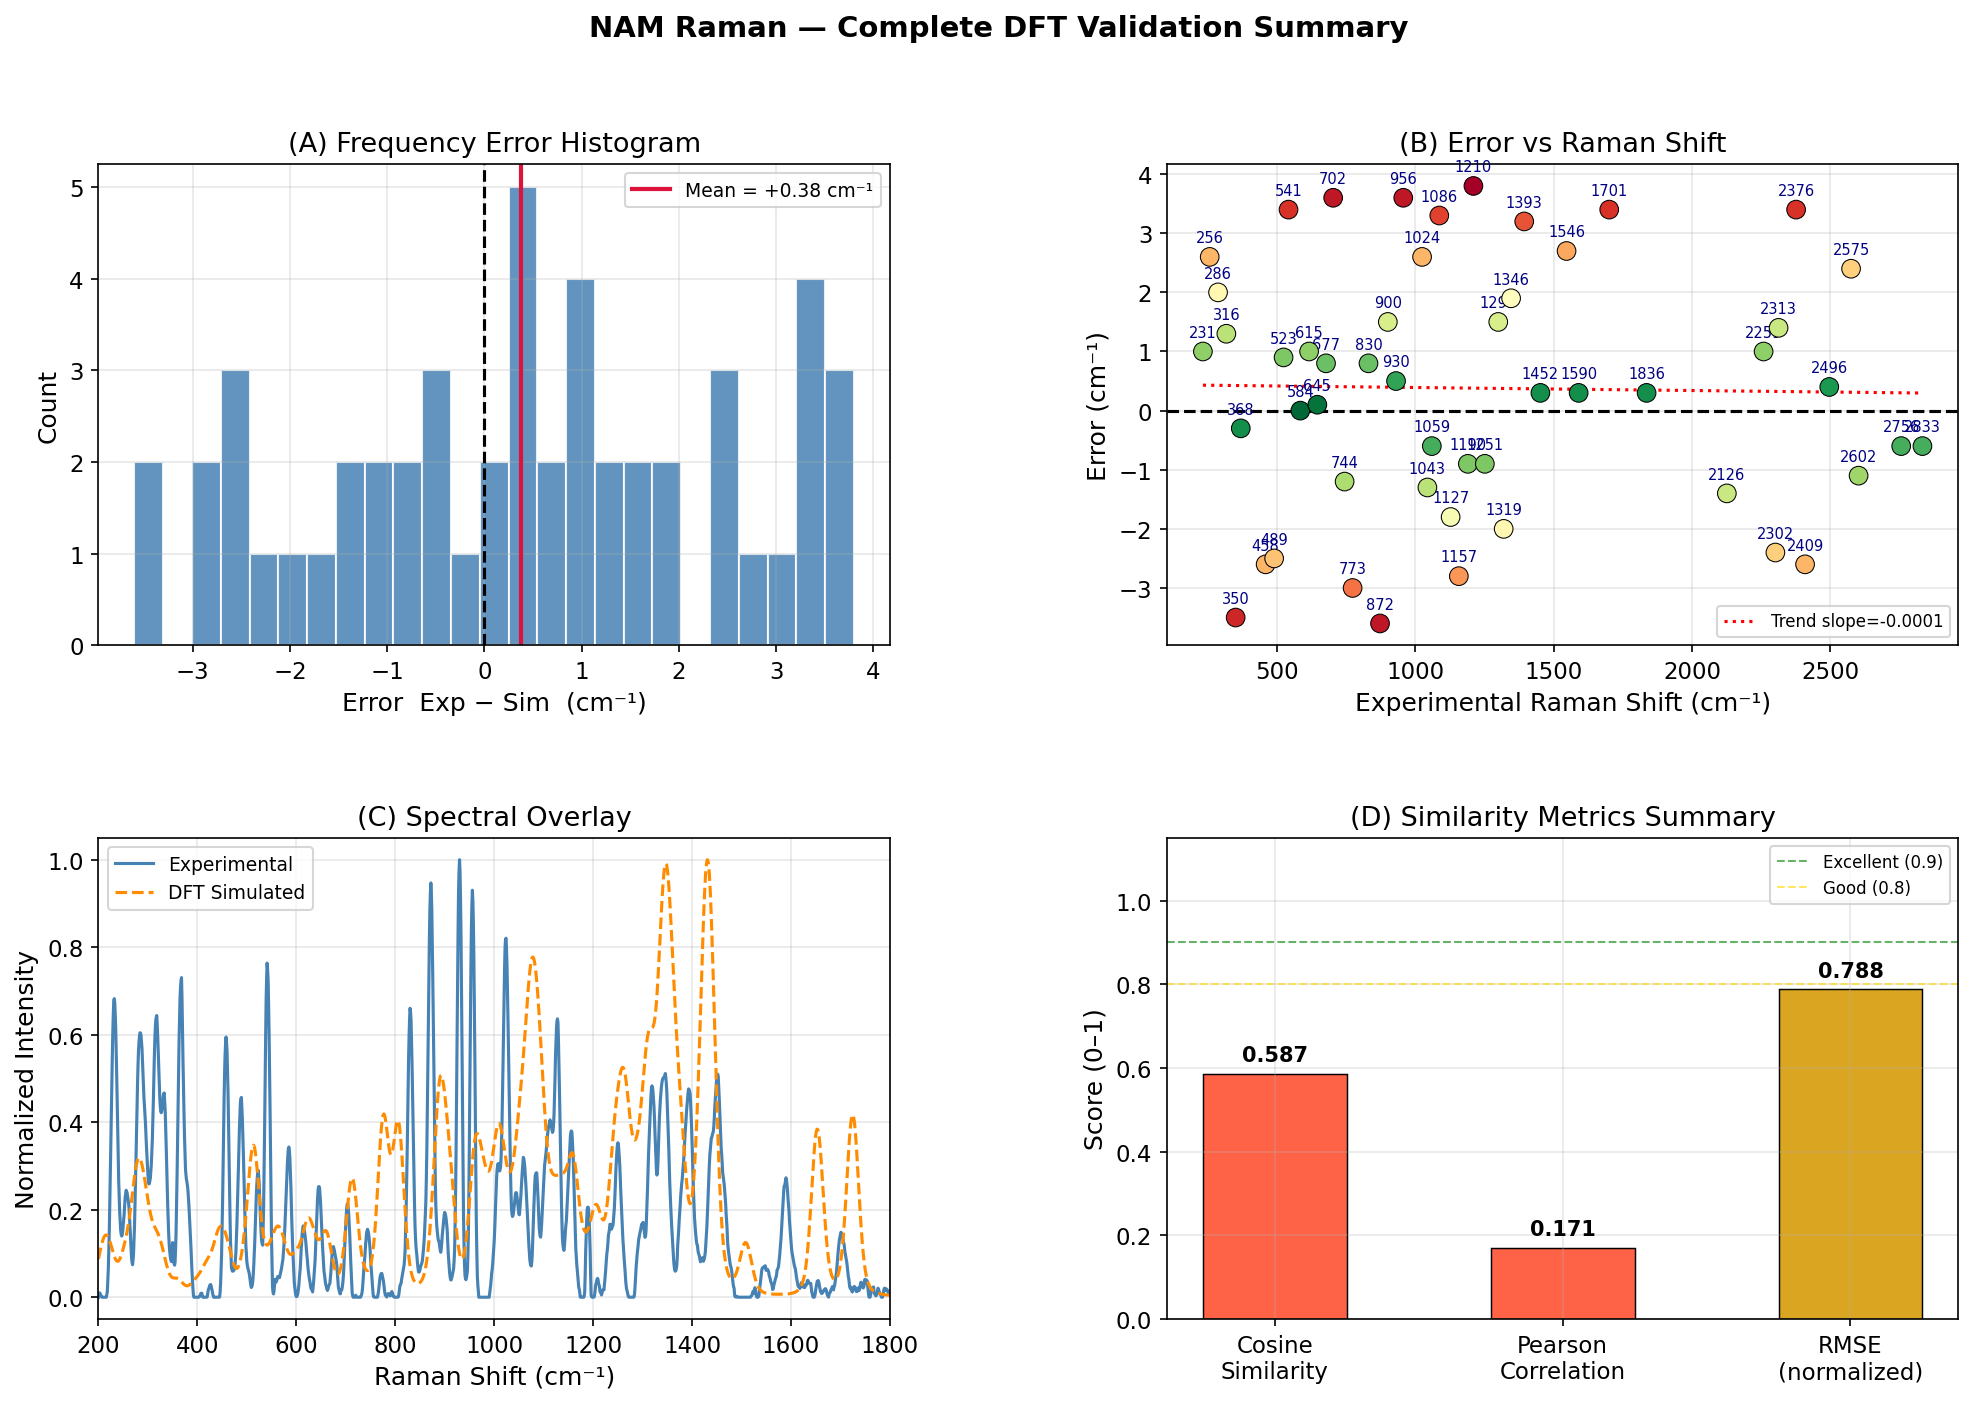

💾 Saved → C:\Users\sukes\Downloads\review meeting\NAM-EXP-P\NAM\output_figures\fig10_validation_summary_4panel.png


In [11]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle('NAM Raman — Complete DFT Validation Summary', fontsize=14, fontweight='bold')

# ── Panel A: Error Histogram ─────────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
ax_a.hist(error, bins=max(6, len(error)//2),
          color='steelblue', edgecolor='white', alpha=0.85)
ax_a.axvline(0,          color='black',  linestyle='--', linewidth=1.5)
ax_a.axvline(mean_error, color='crimson',linewidth=2,
             label=f'Mean = {mean_error:+.2f} cm⁻¹')
ax_a.set_xlabel('Error  Exp − Sim  (cm⁻¹)')
ax_a.set_ylabel('Count')
ax_a.set_title('(A) Frequency Error Histogram')
ax_a.legend(fontsize=9)

# ── Panel B: Error vs Shift ───────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
ax_b.scatter(exp_peaks, error, c=np.abs(error), cmap='RdYlGn_r',
             s=80, edgecolors='k', linewidths=0.5, zorder=5)
ax_b.axhline(0, color='black', linestyle='--', linewidth=1.5)
for xp, ye in zip(exp_peaks, error):
    ax_b.annotate(f'{xp:.0f}', (xp, ye),
                  xytext=(0, 7), textcoords='offset points',
                  fontsize=7, ha='center', color='navy')
if len(exp_peaks) > 2:
    z = np.polyfit(exp_peaks, error, 1)
    x_l = np.linspace(exp_peaks.min(), exp_peaks.max(), 200)
    ax_b.plot(x_l, np.poly1d(z)(x_l), 'r:', linewidth=1.5,
              label=f'Trend slope={z[0]:.4f}')
    ax_b.legend(fontsize=8)
ax_b.set_xlabel('Experimental Raman Shift (cm⁻¹)')
ax_b.set_ylabel('Error (cm⁻¹)')
ax_b.set_title('(B) Error vs Raman Shift')

# ── Panel C: Spectral Overlay ─────────────────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
ax_c.plot(common_grid, exp_interp, color='steelblue', linewidth=1.5, label='Experimental')
ax_c.plot(common_grid, sim_interp, color='darkorange', linewidth=1.5,
          linestyle='--', label='DFT Simulated')
ax_c.set_xlabel('Raman Shift (cm⁻¹)')
ax_c.set_ylabel('Normalized Intensity')
ax_c.set_title('(C) Spectral Overlay')
ax_c.set_xlim(GRID_START, GRID_END)
ax_c.legend(fontsize=9)

# ── Panel D: Summary Metrics Bar ─────────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
metrics      = ['Cosine\nSimilarity', 'Pearson\nCorrelation', 'RMSE\n(normalized)']
# Normalize RMSE to 0–1 scale for visual (inverted: higher bar = better)
rmse_norm    = max(0, 1 - rmse / 10)
values       = [cos_sim, max(0, pearson_corr), rmse_norm]
colors_bar   = ['steelblue' if v >= 0.8 else 'goldenrod' if v >= 0.6 else 'tomato'
                for v in values]
bars = ax_d.bar(metrics, values, color=colors_bar, edgecolor='k', linewidth=0.7, width=0.5)
ax_d.set_ylim(0, 1.15)
ax_d.axhline(0.9, color='green', linestyle='--', linewidth=1, alpha=0.6, label='Excellent (0.9)')
ax_d.axhline(0.8, color='gold',  linestyle='--', linewidth=1, alpha=0.6, label='Good (0.8)')
for bar, val in zip(bars, values):
    ax_d.text(bar.get_x() + bar.get_width() / 2, val + 0.02,
              f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax_d.set_ylabel('Score (0–1)')
ax_d.set_title('(D) Similarity Metrics Summary')
ax_d.legend(fontsize=8)

save_path = os.path.join(OUTPUT_DIR, 'fig10_validation_summary_4panel.png')
plt.savefig(save_path, bbox_inches='tight')
plt.show()
print(f'💾 Saved → {save_path}')

---
## Final Validation Report

In [12]:
print('═' * 65)
print('  NAM RAMAN–DFT VALIDATION FINAL REPORT')
print('═' * 65)
print()
print('  ── Frequency Shift Analysis ──')
print(f'     Matched peaks           : {len(error)}')
print(f'     Mean error              : {mean_error:+.3f} cm⁻¹')
print(f'     Std deviation           : {std_error:.3f} cm⁻¹')
print(f'     RMSE                    : {rmse:.3f} cm⁻¹   → {rmse_quality}')
print()
print('  ── Spectral Similarity ──')
print(f'     Cosine Similarity       : {cos_sim:.4f}   → {rate(cos_sim)}')
print(f'     Pearson Correlation     : {pearson_corr:.4f}   → {rate(pearson_corr)}')
print(f'     Pearson p-value         : {pearson_pval:.2e}')
print()
print('  ── Scientific Interpretation ──')
print(f'     {scale_interp}')
print()
print('  ── Saved Figures ──')
for f in ['fig07_frequency_error_histogram.png',
           'fig08_error_vs_raman_shift.png',
           'fig09_spectral_similarity_overlay.png',
           'fig10_validation_summary_4panel.png']:
    print(f'     ✅ {f}')
print('═' * 65)

═════════════════════════════════════════════════════════════════
  NAM RAMAN–DFT VALIDATION FINAL REPORT
═════════════════════════════════════════════════════════════════

  ── Frequency Shift Analysis ──
     Matched peaks           : 51
     Mean error              : +0.378 cm⁻¹
     Std deviation           : 2.102 cm⁻¹
     RMSE                    : 2.115 cm⁻¹   → 🟢 Excellent  (< 5 cm⁻¹)

  ── Spectral Similarity ──
     Cosine Similarity       : 0.5868   → 🔴 Poor
     Pearson Correlation     : 0.1710   → 🔴 Poor
     Pearson p-value         : 5.73e-12

  ── Scientific Interpretation ──
     ✅ Scaling factor (0.96) appears correct — mean error near 0

  ── Saved Figures ──
     ✅ fig07_frequency_error_histogram.png
     ✅ fig08_error_vs_raman_shift.png
     ✅ fig09_spectral_similarity_overlay.png
     ✅ fig10_validation_summary_4panel.png
═════════════════════════════════════════════════════════════════
